# Random FDLU noising single layer

Created: 23-06-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising.ipynb), but now just apply a single layer FDLU.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

In [6]:
from scipy.stats import ortho_group

In [7]:
from collections import Counter

In [8]:
import pandas as pd

# Definitions
## Groundstates

In [9]:
num_sites = 16

In [10]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [11]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [12]:
parameters = np.linspace(0, 1, 11)

In [13]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [14]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.14it/s]


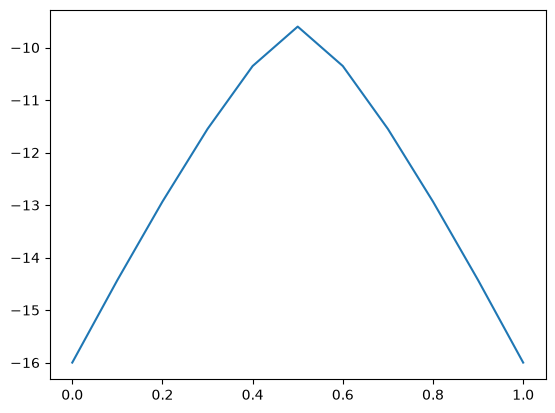

In [15]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [16]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [17]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [18]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [19]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [20]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [21]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [22]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [23]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [24]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [25]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [26]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [27]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [28]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [29]:
def get_tensor_network_factorization(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )

    rho_purity = np.real(np.trace(rho @ rho))

    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [30]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [31]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [32]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [33]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [34]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [35]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [36]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [37]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [38]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {k: (4,4) for k in unfuse_map.keys()}

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [39]:
def extract_time_reversal_information(psi):
    rho = basis.partial_trace(
        psi,
        sub_sys_A=symmetry_sites,
        return_rdm="A",
        enforce_pure=True
    )
    
    rho_purity = np.real(np.trace(rho @ rho))
    
    # Hardcode warning
    rho_reshaped = rho.reshape((16, 16, 16, 16,))
    
    qt_rho = qtn.Tensor(
        data=rho_reshaped,
        inds=('kl', 'kr', 'bl', 'br')
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(psi)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [40]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [41]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for i in range(num_sites//2):
        site_1 = ((2*i))%num_sites
        site_2 = ((2*i)+1)%num_sites

        u = generate_random_symmetry_respecting_unitary()
        
        qu_u = qtn.Tensor(
            u.reshape((2,)*4),
            inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
        )

        qu_psi = (
            qu_psi.reindex(
                {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
            )
            & qu_u
        )
        qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [42]:
def extract_time_reversal_information_after_random_fdlu(psi, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quspin_state(psi)
        out.append(extract_time_reversal_information(rand_psi))

    return out

# Sweep

In [43]:
fixed_point_groundstates = [
    groundstates[0],
    groundstates[-1],
]

In [44]:
sweep_results = list()

for psi in tqdm(fixed_point_groundstates):
    l = extract_time_reversal_information_after_random_fdlu(psi, 20)
    sweep_results.append(l)

  0%|                                                                                                   | 0/2 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:58<00:00, 29.06s/it]


## Analyse results

### Left right rho schmidt values

#### Trivial

In [45]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[0]
]

In [46]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [47]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [48]:
triv_schmidt_vals

[[np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000056)],
 [np.float64(1.0000000000000062)],
 [np.float64(1.0000000000000056)],
 [np.float64(1.0000000000000056)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000062)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000062)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.000000000000006)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.0000000000000078)],
 [np.float64(1.000000000000006)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000064)]]

In [49]:
def get_schmidt_vals_ratio(l):
    if len(l) == 1:
        return 0
    else:
        return l[1]/l[0]

In [50]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [51]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

#### Non-trivial

In [52]:
nontriv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[1]
]

In [53]:
num_nontriv_schmidt_vals = [len(l) for l in nontriv_schmidt_vals]

In [54]:
Counter(num_nontriv_schmidt_vals)

Counter({4: 20})

In [55]:
nontriv_schmidt_vals

[[np.float64(0.25000000000000194),
  np.float64(0.25000000000000183),
  np.float64(0.25000000000000183),
  np.float64(0.2500000000000018)],
 [np.float64(0.2500000000000018),
  np.float64(0.2500000000000018),
  np.float64(0.2500000000000017),
  np.float64(0.2500000000000014)],
 [np.float64(0.2500000000000023),
  np.float64(0.2500000000000019),
  np.float64(0.2500000000000017),
  np.float64(0.2500000000000011)],
 [np.float64(0.2500000000000022),
  np.float64(0.2500000000000019),
  np.float64(0.25000000000000183),
  np.float64(0.2500000000000011)],
 [np.float64(0.2500000000000019),
  np.float64(0.2500000000000019),
  np.float64(0.2500000000000018),
  np.float64(0.2500000000000018)],
 [np.float64(0.25000000000000216),
  np.float64(0.25000000000000194),
  np.float64(0.25000000000000183),
  np.float64(0.25000000000000155)],
 [np.float64(0.2500000000000027),
  np.float64(0.25000000000000205),
  np.float64(0.25000000000000183),
  np.float64(0.2500000000000015)],
 [np.float64(0.2500000000000024

In [56]:
nontriv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in nontriv_schmidt_vals
]

In [57]:
pd.Series(nontriv_schmidt_val_ratios).describe()

count    2.000000e+01
mean     1.000000e+00
std      8.416756e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Hmm...

### Purification full effective density matrix
Output data:
* left_right_singular_vals
* left_defect_op_invariant
* right_defect_op_invariant
* overlaps
* purification_diff_score

#### Trivial

In [58]:
purification_rho_sweep_results = [l[1] for l in sweep_results[0]]

In [59]:
purification_rho_sweep_results[0][0]

array([1.])

In [60]:
purification_rho_sweep_results[-1][0]

array([1.])

In [61]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in purification_rho_sweep_results
]

In [62]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [63]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [64]:
triv_schmidt_vals

[[np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.000000000000006)],
 [np.float64(1.0000000000000056)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000056)],
 [np.float64(1.000000000000005)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.000000000000005)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000049)],
 [np.float64(1.000000000000006)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000053)],
 [np.float64(1.0000000000000058)],
 [np.float64(1.0000000000000058)]]

In [65]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [66]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

This is exactly the same as the corresponding results for $rho$ in the previous section! Is this expected?

In [67]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [68]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(6.661338147750939e-16), np.float64(6.245004513516506e-16))

In [69]:
np.round(left_defect_op_invariants, 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j,
       1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j])

In [70]:
np.round(right_defect_op_invariants, 3)

array([1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j])

In [71]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [72]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [73]:
overlaps = np.real(overlaps[:, -1])

In [74]:
pd.Series(overlaps).describe()

count    2.000000e+01
mean     1.000000e+00
std      8.134550e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [75]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [76]:
defect_results = defect_results[defect_results[:, 0].argsort()]

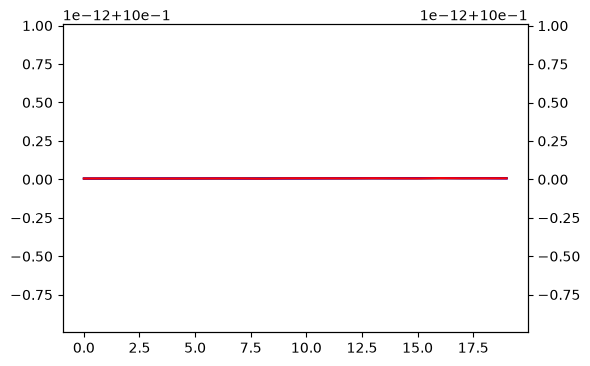

In [77]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [78]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(2.595203131696641e-30)

So this method works, and appears to work well. But why?

#### Non-trivial

In [79]:
purification_rho_sweep_results = [l[1] for l in sweep_results[1]]

In [80]:
purification_rho_sweep_results[0][0]

array([0.04181998, 0.04181998, 0.04181998, 0.04181998])

In [81]:
purification_rho_sweep_results[-1][0]

array([0.02711016, 0.02711016, 0.02711016, 0.02711016])

In [82]:
schmidt_vals = [
    [x for x in l[0] if x > 0.005]
    for l in purification_rho_sweep_results
]

In [83]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [84]:
Counter(num_schmidt_vals)

Counter({4: 17, 0: 3})

In [85]:
purification_rho_sweep_results[0][0]

array([0.04181998, 0.04181998, 0.04181998, 0.04181998])

In [86]:
schmidt_vals

[[np.float64(0.041819977419112885),
  np.float64(0.041819977419112885),
  np.float64(0.041819977419112885),
  np.float64(0.04181997741911288)],
 [np.float64(0.0686758030807119),
  np.float64(0.0686758030807119),
  np.float64(0.0686758030807119),
  np.float64(0.0686758030807119)],
 [],
 [np.float64(0.0605420234803479),
  np.float64(0.0605420234803479),
  np.float64(0.0605420234803479),
  np.float64(0.060542023480347894)],
 [],
 [np.float64(0.09548673928122907),
  np.float64(0.09548673928122907),
  np.float64(0.09548673928122907),
  np.float64(0.09548673928122907)],
 [np.float64(0.030743573322807385),
  np.float64(0.03074357332280736),
  np.float64(0.030743573322807353),
  np.float64(0.03074357332280732)],
 [np.float64(0.026162585616002678),
  np.float64(0.026162585616002678),
  np.float64(0.026162585616002678),
  np.float64(0.026162585616002675)],
 [],
 [np.float64(0.016582977584614186),
  np.float64(0.016582977584614186),
  np.float64(0.016582977584614186),
  np.float64(0.0165829775846

In [87]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

IndexError: list index out of range

In [ ]:
pd.Series(triv_schmidt_val_ratios).describe()

In this case, the results are different!

In [88]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [89]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(1.8596235662471372e-15), np.float64(1.700029006457271e-15))

In [90]:
np.round(left_defect_op_invariants, 3)

array([ 0.118-0.j,  0.029+0.j,  0.293-0.j, -0.973-0.j, -0.344-0.j,
       -0.424-0.j, -0.971-0.j, -0.279-0.j, -0.963-0.j, -0.181-0.j,
       -0.644+0.j, -0.259+0.j, -0.997+0.j, -0.257-0.j, -0.961+0.j,
       -0.411-0.j,  0.75 -0.j, -0.636-0.j, -0.805+0.j, -0.931-0.j])

In [91]:
np.round(right_defect_op_invariants, 3)

array([ 0.118+0.j,  0.029-0.j,  0.293+0.j, -0.973+0.j, -0.344+0.j,
       -0.424+0.j, -0.971+0.j, -0.279+0.j, -0.963+0.j, -0.181+0.j,
       -0.644-0.j, -0.259-0.j, -0.997-0.j, -0.257+0.j, -0.961-0.j,
       -0.411+0.j,  0.75 +0.j, -0.636+0.j, -0.805-0.j, -0.931+0.j])

In [92]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [93]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [94]:
overlaps = np.real(overlaps[:, -1])

In [95]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.194542
std       0.128613
min       0.004502
25%       0.095071
50%       0.237457
75%       0.287130
max       0.414223
dtype: float64

In [96]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [97]:
defect_results = defect_results[defect_results[:, 0].argsort()]

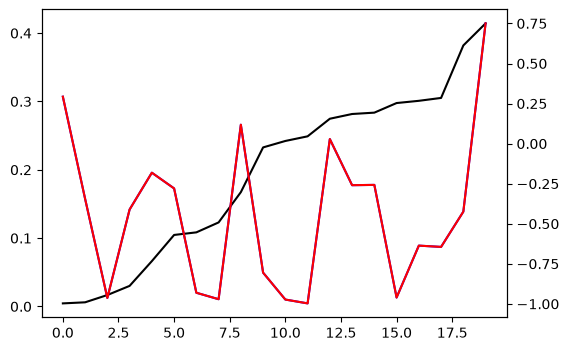

In [98]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [99]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(1.0125976998079676e-30)

### Purificaiton and defect operators on cut states

#### Non-trivial

In [100]:
purification_diffs = [l[2] for l in sweep_results[1]]

In [101]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(1.0125976998079676e-30)

In [102]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[1]]

In [103]:
purification_cut_state_sweep_results[0][0]

[np.float64(0.25000000000000244),
 array([0.03115634, 0.03115634, 0.03115634, 0.03115634]),
 np.complex128(-0.9282867276832745+2.3505503099485736e-16j),
 np.complex128(-0.928286727683274-2.220446049250313e-16j),
 [np.float64(0.18948975437601123),
  np.float64(0.12462537766659515),
  np.float64(0.12462537766659514),
  np.float64(0.12462537766659511),
  np.float64(0.12462537766659507),
  np.float64(0.12462537766659511),
  np.float64(0.12462537766659512),
  np.float64(0.1246253776665951),
  np.float64(0.12462537766659511),
  np.float64(0.1246253776665951),
  np.float64(0.12462537766659514),
  np.float64(0.12462537766659512),
  np.float64(0.12462537766659512),
  np.float64(0.1246253776665951),
  np.float64(0.1246253776665951),
  np.float64(0.12462537766659511),
  np.float64(0.1246253776665951),
  np.float64(0.12462537766659514),
  np.float64(0.12462537766659514),
  np.float64(0.12462537766659512),
  np.float64(0.12462537766659512),
  np.float64(0.12462537766659514),
  np.float64(0.12462537

Won't even analyze, as it doesn't work in the simpler case.

### Tensor network factorizations

#### Trivial

In [104]:
factorization_loss_curves = [l[4] for l in sweep_results[0]]

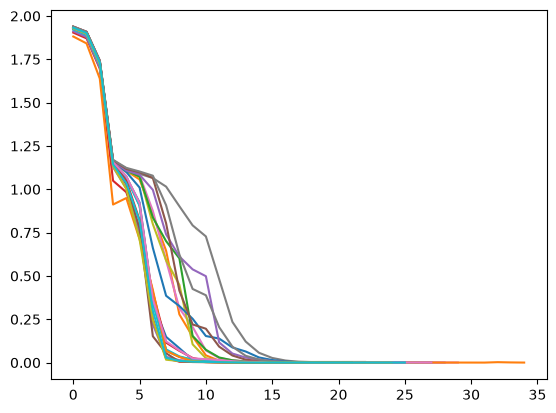

In [105]:
for l in factorization_loss_curves:
    plt.plot(l);

In [106]:
best_loss = [min(l) for l in factorization_loss_curves]

In [107]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.001100
std       0.000989
min       0.000130
25%       0.000349
50%       0.000771
75%       0.001750
max       0.003529
dtype: float64

In [108]:
left_loss = np.array([l[6] for l in sweep_results[0]])
right_loss = np.array([l[7] for l in sweep_results[0]])

In [109]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [110]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [111]:
np.max(left_loss), np.max(right_loss)

(np.float32(1.4064405e-11), np.float32(3.881698e-12))

#### Nontrivial

In [112]:
factorization_loss_curves = [l[4] for l in sweep_results[1]]

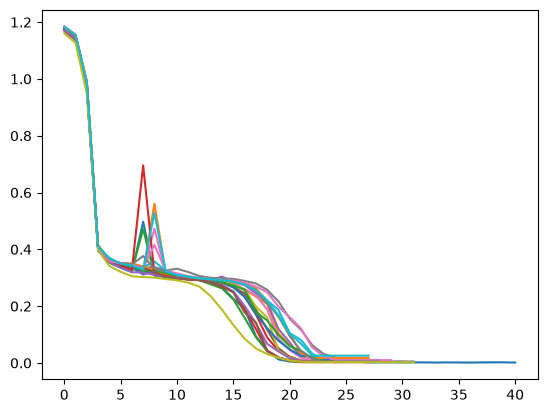

In [113]:
for l in factorization_loss_curves:
    plt.plot(l);

In [114]:
best_loss = [min(l) for l in factorization_loss_curves]

In [115]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.006375
std       0.005886
min       0.001319
25%       0.003167
50%       0.004161
75%       0.006724
max       0.025593
dtype: float64

In [116]:
left_loss = np.array([l[6] for l in sweep_results[1]])
right_loss = np.array([l[7] for l in sweep_results[1]])

In [117]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [118]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [119]:
np.max(left_loss), np.max(right_loss)

(np.float32(9.477702e-12), np.float32(5.8030434e-12))

### Factorized full effective density matrix

#### Trivial

In [120]:
schmidt_vals = [
    [x for x in l[8] if x > 0.05]
    for l in sweep_results[0]
]

In [121]:
schmidt_vals

[[np.float64(0.9559070920228985)],
 [np.float64(0.9809924449346301)],
 [np.float64(0.964453812967346)],
 [np.float64(0.9886911362943781)],
 [np.float64(0.9860862182357925)],
 [np.float64(0.9824156608569052)],
 [np.float64(0.9875051188955474)],
 [np.float64(0.9505773406713769)],
 [np.float64(0.9717591303254125)],
 [np.float64(0.9738363725669795)],
 [np.float64(0.9421732565572293)],
 [np.float64(0.9951225051204504)],
 [np.float64(0.9569091612194387)],
 [np.float64(0.981674296409031)],
 [np.float64(0.9796560796403795)],
 [np.float64(0.9445038777538243)],
 [np.float64(0.9737666154894707)],
 [np.float64(0.9548901357016648)],
 [np.float64(0.9819244972565034)],
 [np.float64(0.9880106575672243)]]

In [122]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [123]:
Counter(num_schmidt_vals)

Counter({1: 20})

In [124]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [125]:
pd.Series(schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [126]:
left_invariants = [l[9] for l in sweep_results[0]]
right_invariants = [l[10] for l in sweep_results[0]]

In [127]:
left_invariants

[np.complex128(1.000000000000004-1.8155499326155677e-10j),
 np.complex128(0.9999999999999923+1.9590828959081819e-10j),
 np.complex128(1.0000000000000042+2.1885243617347783e-10j),
 np.complex128(1.000000000000002-4.743871961920831e-12j),
 np.complex128(1.0000000000000018-2.6203983427564026e-11j),
 np.complex128(1.0000000000000058+6.959099962955406e-12j),
 np.complex128(1.0000000000000036+7.216421904487902e-12j),
 np.complex128(1.0000000000000022+1.762923140802286e-11j),
 np.complex128(1.0000000000000064-6.662186080585997e-11j),
 np.complex128(1.000000000000002+5.868816543852517e-11j),
 np.complex128(1.0000000000000058+2.7892022025355345e-11j),
 np.complex128(1.0000000000000044+3.863243058788157e-12j),
 np.complex128(1.0000000000000067-1.667416205108907e-12j),
 np.complex128(1.0000000000000022-3.595987396742828e-11j),
 np.complex128(1.0000000000000024+6.765998872282353e-11j),
 np.complex128(0.9999999999999285-1.1549218803530437e-09j),
 np.complex128(1.0000000000000022-6.63308574733179e-1

In [128]:
right_invariants

[np.complex128(1.0000000000000064+2.9789781752498357e-11j),
 np.complex128(1.0000000000000047+5.974234995598238e-11j),
 np.complex128(1.0000000000000018+8.383702065906107e-11j),
 np.complex128(1.0000000000000053+2.1200263766729677e-12j),
 np.complex128(1.000000000000004-9.954037594184229e-12j),
 np.complex128(0.9999999999999939+1.590130110917798e-10j),
 np.complex128(0.9999999999999997-4.5965578565621e-11j),
 np.complex128(1.0000000000000029-9.972112025025126e-11j),
 np.complex128(1.0000000000000049-3.9390907202729863e-11j),
 np.complex128(1.0000000000000027+5.1476295448438236e-11j),
 np.complex128(1.0000000000000027-1.5131895736431034e-11j),
 np.complex128(1.0000000000000044+2.9298008463740643e-11j),
 np.complex128(1.000000000000005-1.6265777613710952e-10j),
 np.complex128(1.000000000000003+6.115871697964792e-11j),
 np.complex128(0.9999999999999785-2.5358326549707044e-10j),
 np.complex128(1.0000000000000047-9.800665834447386e-11j),
 np.complex128(1.0000000000000049+6.819764197807388e-

In [129]:
overlaps = np.array([l[11][-1] for l in sweep_results[0]])

In [130]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [131]:
overlaps = np.real(overlaps)

In [132]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.981976
std       0.012377
min       0.952590
25%       0.976801
50%       0.984802
75%       0.990675
max       0.996155
dtype: float64

In [133]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [134]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

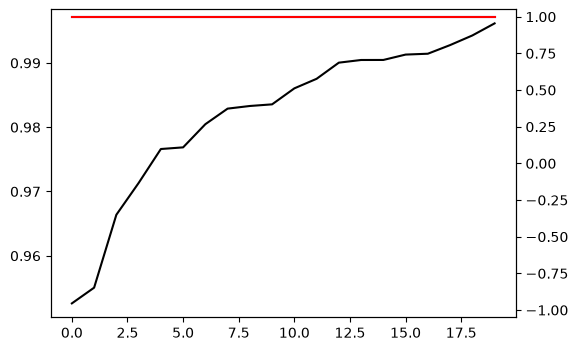

In [135]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

#### Nontrivial

In [136]:
schmidt_vals = [
    [x for x in l[8] if x > 0.005]
    for l in sweep_results[1]
]

In [137]:
schmidt_vals

[[],
 [np.float64(0.0064715758734210805),
  np.float64(0.005255988795500282),
  np.float64(0.005171303403214743)],
 [np.float64(0.005641508866419611)],
 [np.float64(0.007411167551814215)],
 [],
 [np.float64(0.006353405155098007)],
 [np.float64(0.00630878613398173)],
 [np.float64(0.007773869557894398),
  np.float64(0.0058983932244055515),
  np.float64(0.005463047332154425)],
 [],
 [],
 [np.float64(0.005079055942629904)],
 [np.float64(0.009283095158777345), np.float64(0.005010337636060667)],
 [np.float64(0.006566568502256164), np.float64(0.005635946285709261)],
 [np.float64(0.006128611102744863)],
 [np.float64(0.0073351451446230734)],
 [np.float64(0.005923937948021775)],
 [np.float64(0.010200813313268319),
  np.float64(0.008471655218738017),
  np.float64(0.006807875208057325),
  np.float64(0.005752612971878555)],
 [np.float64(0.005476497836383203)],
 [],
 [np.float64(0.012462997920518373),
  np.float64(0.007380141939980534),
  np.float64(0.006047103590707774),
  np.float64(0.005655565412

In [138]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [139]:
Counter(num_schmidt_vals)

Counter({1: 9, 0: 5, 3: 2, 2: 2, 4: 2})

In [140]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

IndexError: list index out of range

In [141]:
pd.Series(schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

A bit more entangled...

In [142]:
left_invariants = [l[9] for l in sweep_results[1]]
right_invariants = [l[10] for l in sweep_results[1]]

In [143]:
left_invariants

[np.complex128(0.9999999999993092+1.3877787807814457e-17j),
 np.complex128(0.9999714710542482+0j),
 np.complex128(0.9999999999938258+0j),
 np.complex128(0.9999999999982665+0j),
 np.complex128(0.999999999997531-1.3877787807814457e-17j),
 np.complex128(0.9999999999926178+8.326672684688674e-17j),
 np.complex128(0.9999999999971124+0j),
 np.complex128(0.9999999064511493+0j),
 np.complex128(0.9999999999918796+4.163336342344337e-17j),
 np.complex128(0.9999225564960339+3.469446951953614e-17j),
 np.complex128(0.9999999999897472+0j),
 np.complex128(0.9999999999982826+1.3877787807814457e-17j),
 np.complex128(0.9999999936573865-1.3877787807814457e-17j),
 np.complex128(0.9999999999934961-1.3877787807814457e-17j),
 np.complex128(0.9999999999915472+0j),
 np.complex128(0.9999999999991174-5.551115123125783e-17j),
 np.complex128(0.9999999999889153-6.938893903907228e-18j),
 np.complex128(0.9999999999975722+2.7755575615628914e-17j),
 np.complex128(0.9999999997574291+2.7755575615628914e-17j),
 np.complex12

In [144]:
right_invariants

[np.complex128(0.9999999999897571+2.7755575615628914e-17j),
 np.complex128(0.9999571635587807+1.3877787807814457e-17j),
 np.complex128(0.9999999999649887-1.3877787807814457e-17j),
 np.complex128(0.9999999999848772+2.7755575615628914e-17j),
 np.complex128(0.9999999999341713+1.3877787807814457e-17j),
 np.complex128(0.9999999999861098+0j),
 np.complex128(0.9999999999519178-5.551115123125783e-17j),
 np.complex128(0.9999998695886041-3.469446951953614e-18j),
 np.complex128(0.9999999999515441-1.3877787807814457e-17j),
 np.complex128(0.9998813647628462-2.7755575615628914e-17j),
 np.complex128(0.9999999999643261+0j),
 np.complex128(0.9999999999833469+0j),
 np.complex128(0.9999999802889311-4.163336342344337e-17j),
 np.complex128(0.9999999999549839-2.0816681711721685e-17j),
 np.complex128(0.9999999999467288+2.7755575615628914e-17j),
 np.complex128(0.999999999993975-1.3877787807814457e-17j),
 np.complex128(0.9999999999670695+0j),
 np.complex128(0.9999999999880346+0j),
 np.complex128(0.999999999541

In [145]:
overlaps = np.array([l[11][-1] for l in sweep_results[1]])

In [146]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [147]:
overlaps = np.real(overlaps)

In [148]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.019482
std       0.005350
min       0.011409
25%       0.015848
50%       0.018660
75%       0.019889
max       0.033418
dtype: float64

In [149]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [150]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

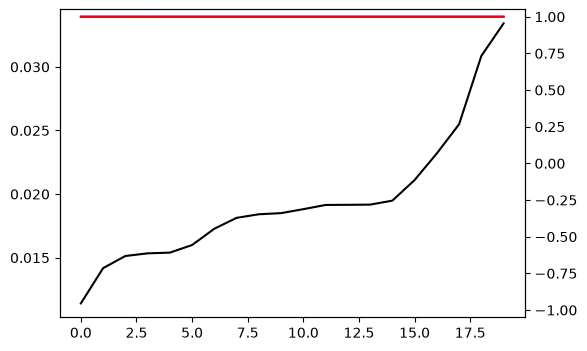

In [151]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

### Factorized cut states

#### Trivial

In [152]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[0]]

In [153]:
factorized_cut_state_sweep_results[0][0]

[np.float32(1.3881111),
 np.float32(0.7045652),
 array([9.99963172e-01, 3.31937060e-04, 3.31132784e-04, 1.42964181e-04,
        1.37958715e-04, 1.22573644e-05, 1.22077428e-05, 2.43130470e-06,
        7.32500667e-07, 2.19043389e-07, 1.32021369e-07, 2.16028265e-08,
        2.09897505e-08, 1.21902637e-08, 7.20775381e-09, 8.07138079e-10]),
 np.complex128(1.0000000298023233-1.3877787807814457e-16j),
 np.complex128(0.999999964609743+3.795139491558075e-08j),
 np.float64(0.9999813159663249)]

In [154]:
all_left_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [155]:
all_left_indices

[np.complex128(0.999999964609743+3.795139491558075e-08j),
 np.complex128(1.0000000563450164-5.38420974471876e-10j),
 np.complex128(1.0000000074505808-9.313226023710541e-10j),
 np.complex128(1.000000119209289-1.7229467436097323e-08j),
 np.complex128(1.0000000000000013-2.2118911147117615e-09j),
 np.complex128(1.0000001788139343+6.984919309616089e-09j),
 np.complex128(1.00000006146729-8.614734064993357e-09j),
 np.complex128(0.9999996349215508-7.21775000878111e-09j),
 np.complex128(1.0000001639127731+1.5832483768463135e-08j),
 np.complex128(1.000000104308128+3.0267984230114564e-09j),
 np.complex128(1.0000001341104507-1.9324943451026755e-08j),
 np.complex128(0.9999999403953523+3.3526927289972974e-08j),
 np.complex128(1.0000000000000004-4.4237822675874394e-09j),
 np.complex128(0.9999997625127435+2.7124769992614706e-08j),
 np.complex128(0.9999999776482574+6.679329075942597e-09j),
 np.complex128(0.9999999999999998+5.0291419001480264e-08j),
 np.complex128(0.9999999180436134-1.4435499906539917e-

In [156]:
all_right_indices = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [157]:
all_right_indices

[np.float64(0.9999813159663249),
 np.float64(0.9999762859868428),
 np.float64(0.9999837949167002),
 np.float64(0.9999880469999665),
 np.float64(0.9999841714282761),
 np.float64(0.9999952836662676),
 np.float64(0.9999904831069404),
 np.float64(0.9999330277482027),
 np.float64(0.9999549453408423),
 np.float64(0.9999883333101358),
 np.float64(0.9997615190245734),
 np.float64(0.9999651549293197),
 np.float64(0.9999673310723489),
 np.float64(0.9999973948728974),
 np.float64(0.9998011110813217),
 np.float64(0.999964990099542),
 np.float64(0.9999942312303061),
 np.float64(0.9999567204113908),
 np.float64(0.9999965774388857),
 np.float64(0.9999961251814383)]

Good overlaps.

#### Nontrivial

In [158]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[1]]

In [159]:
factorized_cut_state_sweep_results[0][0]

[np.float32(1.4256254),
 np.float32(1.4541022),
 array([1.29149858e-02, 1.16493450e-02, 1.04448082e-02, 9.78337004e-03,
        5.53870030e-03, 4.64960445e-03, 3.31593565e-03, 2.57530540e-03,
        1.81531294e-03, 1.65124840e-03, 1.47374290e-03, 1.26266658e-03,
        7.49199417e-05, 6.41657661e-05, 4.43019703e-05, 6.94501854e-06]),
 np.complex128(0.9999622975540157-1.992638322956264e-06j),
 np.complex128(0.9999448500569414-3.090512570355988e-05j),
 np.float64(0.03435581172135397)]

In [160]:
all_left_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [161]:
all_left_indices

[np.complex128(0.9999448500569414-3.090512570355988e-05j),
 np.complex128(1.0000001788139357-9.221749877608154e-09j),
 np.complex128(1.0000000893426906+3.909435111401627e-08j),
 np.complex128(1.0000001192092896-9.021440400269753e-10j),
 np.complex128(-0.1781424616259706+0.0006389067248029068j),
 np.complex128(0.0005515041425882133+0.00029057574954799437j),
 np.complex128(1.000000029801828-6.143243351519612e-09j),
 np.complex128(0.9999996183125878-7.492999534966516e-06j),
 np.complex128(0.9999997913064635+4.401079620186543e-08j),
 np.complex128(0.9999997778451758+1.4748887982446446e-06j),
 np.complex128(0.9999997913835665-9.78242870042223e-09j),
 np.complex128(0.9999999223439128+1.7330393578540715e-07j),
 np.complex128(0.9999038124873156-5.276368108830809e-05j),
 np.complex128(0.999999984852951-2.2824823343869927e-07j),
 np.complex128(0.9999999547530627+3.404710602339378e-08j),
 np.complex128(0.9999999397872676+5.731186422108792e-07j),
 np.complex128(1.0000000294021736-7.440545479742156

In [162]:
all_right_indices = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [163]:
all_right_indices

[np.float64(0.03435581172135397),
 np.float64(0.027557786190049817),
 np.float64(0.01876856307660131),
 np.float64(0.02036508089077542),
 np.float64(0.03643089974374067),
 np.float64(0.018706188241825225),
 np.float64(0.03244411589967855),
 np.float64(0.018184712087464954),
 np.float64(0.0347996792767743),
 np.float64(0.01897766039382335),
 np.float64(0.03051036743622269),
 np.float64(0.017822649658250398),
 np.float64(0.028359344056138415),
 np.float64(0.01925305073911081),
 np.float64(0.02663078568376048),
 np.float64(0.018889504634088138),
 np.float64(0.02074320292316437),
 np.float64(0.021038781121755522),
 np.float64(0.01958715602879119),
 np.float64(0.025946644198260323),
 np.float64(0.025702982419372584),
 np.float64(0.020390734986197662),
 np.float64(0.03150064030937315),
 np.float64(0.026663209663396463),
 np.float64(0.01299878879795686),
 np.float64(0.01686499202598047),
 np.float64(0.012976862955444186),
 np.float64(0.012324770745156283),
 np.float64(0.03735607535270961),
 n

# Conclusions
Something wrong, debug.